# Assignment 6

Smooth the image using averaging, weighted h(x,y)=max(|x|,|y|), and Gaussian filters. Filter size, sigma and padding method are taken from the user.


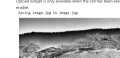

In [1]:
import cv2
import numpy as np

img = cv2.imread('images/sample_image.jpg')
B = img[:, :, 0].astype(np.float64)
G = img[:, :, 1].astype(np.float64)
R = img[:, :, 2].astype(np.float64)
gray = ((R + G + B) / 3).astype(np.uint8)


## Manual Padding and Convolution


In [2]:
def pad_image(image, pad, method):
    h, w = image.shape
    padded = np.zeros((h + 2*pad, w + 2*pad), dtype=np.float64)
    padded[pad:pad+h, pad:pad+w] = image
    if method == 'replicate':
        padded[:pad, pad:pad+w] = image[0, :]
        padded[pad+h:, pad:pad+w] = image[-1, :]
        padded[:, :pad] = padded[:, pad:pad+1]
        padded[:, pad+w:] = padded[:, pad+w-1:pad+w]
    return padded

def apply_filter(image, kernel, method):
    k = kernel.shape[0]
    pad = k // 2
    padded = pad_image(image, pad, method)
    h, w = image.shape
    output = np.zeros((h, w), dtype=np.float64)
    for i in range(h):
        for j in range(w):
            region = padded[i:i+k, j:j+k]
            output[i, j] = np.sum(region * kernel)
    return np.clip(output, 0, 255).astype(np.uint8)


In [3]:
filter_size = int(input('Enter odd filter size: '))
padding = input('Enter padding method (zero/replicate): ').strip().lower()
sigma = float(input('Enter sigma for Gaussian filter: '))
print('Filter size:', filter_size)
print('Padding:', padding)
print('Sigma:', sigma)


Enter odd filter size: 3
Enter padding method (zero/replicate): replicate
Enter sigma for Gaussian filter: 1.0
Filter size: 3
Padding: replicate
Sigma: 1.0


## 1. Averaging Filter


In [4]:
average_kernel = np.ones((filter_size, filter_size), dtype=np.float64)
average_kernel = average_kernel / average_kernel.sum()
average_output = apply_filter(gray, average_kernel, padding)
cv2.imwrite('outputs/assignment6/averaging_filter.jpg', average_output)


## 2. Weighted Filter


[[0.125 0.125 0.125]
 [0.125 0.    0.125]
 [0.125 0.125 0.125]]


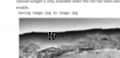

In [5]:
half = filter_size // 2
weighted_kernel = np.zeros((filter_size, filter_size), dtype=np.float64)
for i, x in enumerate(range(-half, half + 1)):
    for j, y in enumerate(range(-half, half + 1)):
        weighted_kernel[i, j] = max(abs(x), abs(y))
if weighted_kernel.sum() == 0:
    weighted_kernel[half, half] = 1
weighted_kernel = weighted_kernel / weighted_kernel.sum()
weighted_output = apply_filter(gray, weighted_kernel, padding)
cv2.imwrite('outputs/assignment6/weighted_filter.jpg', weighted_output)
print(weighted_kernel)


## 3. Gaussian Filter


In [6]:
gaussian_kernel = np.zeros((filter_size, filter_size), dtype=np.float64)
for i, x in enumerate(range(-half, half + 1)):
    for j, y in enumerate(range(-half, half + 1)):
        gaussian_kernel[i, j] = np.exp(-(x*x + y*y) / (2 * sigma * sigma))
gaussian_kernel = gaussian_kernel / gaussian_kernel.sum()
gaussian_output = apply_filter(gray, gaussian_kernel, padding)
cv2.imwrite('outputs/assignment6/gaussian_filter.jpg', gaussian_output)
print(gaussian_kernel)


[[0.07511361 0.1238414  0.07511361]
 [0.1238414  0.20417996 0.1238414 ]
 [0.07511361 0.1238414  0.07511361]]
